# Descriptive statistics and PPGR outcomes

This notebook describes the analysis cohort and the four two-hour postprandial glucose response (PPGR) outcomes: maximum glucose, two-hour glucose, peak duration, and positive incremental area under the curve (iAUC).

## Notebook flow

1. Summarize participant characteristics, monitoring duration, and meal counts.
2. Examine free-living outcome correlations and principal components.
3. Estimate between- and within-participant variance components and relate typical responses to meal-to-meal variability.
4. Compare outcome repeatability for free-living meals and each standardized meal type.

## Outputs

No CSV files are exported by this notebook; summary tables are displayed in the notebook. The following figures are saved to `Figures/`:

- `panel_1_ppgr_outcome_correlation_heatmap.svg`: correlations between free-living PPGR outcomes.
- `panel_1_PPGR_outcomes_pca_loadings.svg`: outcome PCA loadings.
- `panel_1_icc_freeliving_vs_standardized.svg`: repeatability by meal type.

## 1. Setup

Resolve project paths, import the required packages, and load the common prepared meal-level dataset.

In [1]:
from pathlib import Path
import sys

# Find the project when launched from its root, Code/, or a notebook subfolder.
for PROJECT_ROOT in (Path.cwd().resolve(), *Path.cwd().resolve().parents):
    CODE_DIR = PROJECT_ROOT / "Code"
    if (CODE_DIR / "data_paths.py").is_file():
        break
else:
    raise FileNotFoundError("Open this notebook from within the project directory.")

if str(CODE_DIR) not in sys.path:
    sys.path.insert(0, str(CODE_DIR))

# Shared defaults; override individual paths here if needed.
from data_paths import DATA_DIR, METADATA_PATH, MEAL_DATA_PATH, CGM_METRICS_PATH
FIGURES_DIR = PROJECT_ROOT / "Figures"
RESULTS_DIR = PROJECT_ROOT / "Results"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


In [2]:
import logging
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

In [3]:
from utils import load_and_prepare_data

In [4]:
meta_data, data, id_to_subject_key, _ = load_and_prepare_data(
    METADATA_PATH,
    MEAL_DATA_PATH,
)

print(f"Prepared {len(data):,} meals from {data['subject_key'].nunique():,} participants.")

meal-count filter (>15): 995 -> 992 subjects, 3 removed
meals removed: 40
data shape : (54987, 134)
Prepared 54,987 meals from 992 participants.


## 2. Cohort and outcome definitions

Define the four PPGR outcomes and summarize their distributions and the participants represented in the prepared data.

In [5]:
prediction_metrics = [
"max_glucose",
"end_glucose",
"peak_duration",
"positive_iAUC"
]
data[prediction_metrics].describe()

,max_glucose,end_glucose,peak_duration,positive_iAUC
count,54987.000000,54987.000000,54987.000000,54987.000000
mean,118.062274,99.191401,87.383291,1346.821722
std,23.362494,18.515803,37.305025,1326.821507
min,41.220000,39.600000,0.000000,0.000000
25%,102.600000,86.940000,64.601175,324.000000
50%,115.200000,97.200000,103.229167,999.000000
75%,130.320000,109.320000,120.000000,1964.868000
max,309.600000,281.760000,120.000000,13651.200000


### Participant and observation summaries

Restrict the metadata to participants represented in the analysis data, then summarize sex, cohort membership, age, BMI, monitoring duration, and meal counts. Counts are reported for all meals and separately for free-living and standardized meals.

In [6]:
pop = meta_data[meta_data["subject_key"].isin(data["subject_key"])]

In [7]:
pop["gender"].value_counts()

gender
female    563
male      429
Name: count, dtype: int64

In [8]:
pop["cohort"].value_counts()

cohort
cohort_b    848
cohort_c    144
Name: count, dtype: int64

In [9]:
pop[["age", "bmi"]].describe()

,age,bmi
count,992.000000,992.000000
mean,39.729839,23.638570
std,12.060041,3.596398
min,19.000000,16.298186
25%,30.000000,21.058233
50%,38.500000,22.985398
75%,48.000000,25.407852
max,77.000000,47.176658


In [10]:
print("observation length:")
data.groupby("subject_key")["eaten_date"].nunique().describe()#["mean"]

observation length:


count    992.000000
mean      15.621976
std        5.076532
min        7.000000
25%       14.000000
50%       14.000000
75%       14.000000
max       48.000000
Name: eaten_date, dtype: float64

In [11]:
print("Data counts: all meals")
data.groupby("subject_key")["eaten_at"].nunique().describe()#["mean"]

Data counts: all meals


count    992.000000
mean      55.430444
std       18.927905
min       17.000000
25%       46.000000
50%       51.500000
75%       57.000000
max      166.000000
Name: eaten_at, dtype: float64

In [12]:
print("Data counts: free-living meals")

data[data["is_standardized_meal"]==0].groupby(
    "subject_key")["eaten_at"].nunique().describe()#["mean"]

Data counts: free-living meals


count    992.000000
mean      50.869960
std       17.675578
min       12.000000
25%       41.750000
50%       47.000000
75%       53.000000
max      150.000000
Name: eaten_at, dtype: float64

In [13]:
print("Data counts: standardized meals")

data[data["is_standardized_meal"]==1].groupby(
    "subject_key")["eaten_at"].nunique().describe()#["mean"]

Data counts: standardized meals


count    963.000000
mean       4.697819
std        2.220923
min        1.000000
25%        3.000000
50%        5.000000
75%        6.000000
max       16.000000
Name: eaten_at, dtype: float64

## 3. Free-living PPGR outcomes

Summarize the four outcomes for free-living meals, examine their pairwise correlations, and obtain a PCA representation. Estimate between- and within-participant variance components for free-living outcomes; the final descriptive correlation check uses all meal types to relate each participant's median response to their meal-to-meal standard deviation.

Overall data shape (54987, 133)
Free-living meals data shape (50463, 133)
Standardized meals shape (4524, 133)
pairwise correlation:


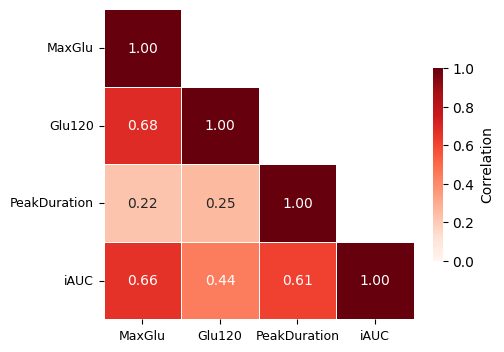

In [14]:
print("Overall data shape", data.shape)
print("Free-living meals data shape", data[data["is_standardized_meal"]==0].shape)
print("Standardized meals shape", data[data["is_standardized_meal"]==1].shape)

prediction_metrics = [
"max_glucose",
"end_glucose",
"peak_duration",
"positive_iAUC"
]

rename_metrics = {
    "max_glucose": "MaxGlu",
    "end_glucose": "Glu120",
    "peak_duration": "PeakDuration",
    "positive_iAUC": "iAUC",
}
ppgr_outcomes = data[["max_glucose", "end_glucose", "peak_duration", "positive_iAUC"]].copy().rename(columns=rename_metrics)

print("pairwise correlation:")
corr = ppgr_outcomes.corr().round(2)

# Mask the upper triangle, but keep the diagonal
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

plt.figure(figsize=(5, 5))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="Reds",
    vmin=0,
    square=True,
    linewidths=0.5,
    cbar_kws={
        "shrink": 0.5,
        "label": "Correlation",
    },
)

plt.xticks(rotation=0, fontsize=9)
plt.yticks(rotation=0, fontsize=9)

plt.savefig(
    FIGURES_DIR / "panel_1_ppgr_outcome_correlation_heatmap.svg",
    format="svg",
    bbox_inches="tight",
)

plt.show()

PCA of outcomes:
variance explained per components
[0.61365744 0.24439399 0.09895231 0.04299627]
                   PC1       PC2       PC3       PC4
MaxGlu        0.532307 -0.436830 -0.350541  0.634783
Glu120        0.505385 -0.427017  0.662040 -0.352059
PeakDuration  0.394390  0.739190  0.382739  0.389314
iAUC          0.552894  0.283610 -0.540679 -0.567045


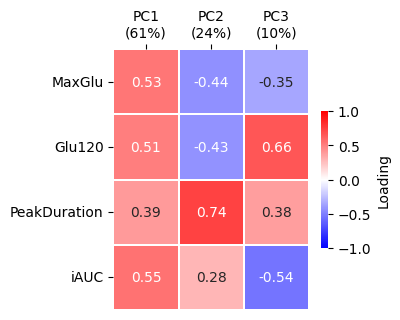

In [15]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

prediction_metrics = [
"max_glucose",
"end_glucose",
"peak_duration",
"positive_iAUC"
]

rename_metrics = {
    "max_glucose": "MaxGlu",
    "end_glucose": "Glu120",
    "peak_duration": "PeakDuration",
    "positive_iAUC": "iAUC",
}

ppgr_outcomes = data[data["is_standardized_meal"]==0][prediction_metrics].copy().rename(columns=rename_metrics)

X = StandardScaler().fit_transform(ppgr_outcomes)

pca = PCA()
pcs = pca.fit_transform(X)


print("PCA of outcomes:")
print("variance explained per components")
print(pca.explained_variance_ratio_)

loadings_df = pd.DataFrame(
    pca.components_.T,
    index=ppgr_outcomes.columns,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)]
)

print(loadings_df)

##### plot 
explained = pca.explained_variance_ratio_[:4] * 100

xticklabels = [
    f"PC{i+1}\n({v:.0f}%)"
    for i, v in enumerate(explained)
]
sns.reset_defaults()

plt.figure(figsize=(4, 5))
ax = sns.heatmap(
    loadings_df.iloc[:, :3],
    annot=True,
    fmt=".2f",
    cmap="bwr",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.01,
    cbar_kws={
        "label": "Loading",
        "shrink": 0.3,
    },
    xticklabels=xticklabels[:3],
)
ax.xaxis.tick_top()                 # Move tick labels to the top
ax.xaxis.set_label_position('top')  

plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()

plt.savefig(FIGURES_DIR / "panel_1_PPGR_outcomes_pca_loadings.svg", format="svg", bbox_inches="tight")
plt.show()

In [16]:
pcs = pca.fit_transform(X)

df_pca = data[data["is_standardized_meal"] == 0].copy()

df_pca["PPGR_PC1"] = pcs[:, 0]
df_pca["PPGR_PC2"] = pcs[:, 1]
df_pca["PPGR_PC3"] = pcs[:, 2]
df_pca["PPGR_PC4"] = pcs[:, 3]

In [17]:
import pandas as pd
import statsmodels.formula.api as smf
from tqdm import tqdm

icc_results = []

rename_metrics = {
    "max_glucose": "MaxGlu",
    "end_glucose": "Glu120",
    "peak_duration": "PeakDuration",
    "positive_iAUC": "iAUC",
}

df_variance_decomposition = data[data["is_standardized_meal"]==False][["subject_key", 
                                                    "mealtime_type"] +
                                                    prediction_metrics].dropna().copy().rename(columns=rename_metrics)
icc_outcomes = rename_metrics.values()
for outcome in tqdm(icc_outcomes):

    df = df_variance_decomposition.copy()
    model = smf.mixedlm(
        f"{outcome} ~ 1",
        data=df_variance_decomposition,
        groups="subject_key",
    )

    fit = model.fit(
        reml=True,
        method="powell",
        maxiter=5000,
        disp=False,
    )

    var_between = fit.cov_re.iloc[0, 0]
    var_within = fit.scale

    icc = var_between / (var_between + var_within)

    icc_results.append({
        "outcome": outcome,
        "between_std": np.round(np.sqrt(var_between),1),
        "within_std": np.round(np.sqrt(var_within), 1),
        "ICC": np.round(icc, 3),
        "converged":fit.converged,
    })

icc_df = pd.DataFrame(icc_results)
print(icc_df)

100%|██████████| 4/4 [00:11<00:00,  2.94s/it]

        outcome  between_std  within_std    ICC  converged
0        MaxGlu         12.9        18.2  0.335       True
1        Glu120         10.5        14.8  0.333       True
2  PeakDuration          4.7        37.7  0.015       True
3          iAUC        365.5      1167.1  0.089       True


In [18]:
import pandas as pd
from scipy import stats
print("Associations between median and STD of PPGR outcomes:")
ID = "subject_key"
METRICS = prediction_metrics
MIN_MEALS = 1

rows = []
for m in METRICS:
    g = data[[ID, m]].dropna().groupby(ID)[m]
    pp = pd.DataFrame({"median": g.median(), "sd": g.std(ddof=1), "n": g.size()})
    pp = pp[pp["n"] >= MIN_MEALS].dropna()
    rows.append({
        "outcome": m,
        "n_participants": len(pp),
        "pearson": stats.pearsonr(pp["median"], pp["sd"])[0],
        "spearman": stats.spearmanr(pp["median"], pp["sd"])[0],
    })

print(pd.DataFrame(rows).set_index("outcome").round(3).to_string())

Associations between median and STD of PPGR outcomes:
               n_participants  pearson  spearman
outcome                                         
max_glucose               992    0.402     0.371
end_glucose               992    0.331     0.229
peak_duration             992   -0.253    -0.217
positive_iAUC             992    0.534     0.525


## 4. Repeatability by meal type

Compare response repeatability for free-living meals and the three standardized challenges. Report single-meal and average-meal ICC estimates for each outcome and meal type.

In [19]:
import numpy as np, pandas as pd
import statsmodels.formula.api as smf
from tqdm import tqdm

icc_results = []
for meal_id in ["A", "B", "C", "other"]:
    for outcome in tqdm(prediction_metrics, desc=meal_id):
        sub = data[data["standardized_meal_id"] == meal_id]
        df  = sub[["subject_key", outcome]].dropna().copy()

        fit = smf.mixedlm(f"{outcome} ~ 1", df, groups="subject_key").fit(
            reml=True, method="powell", maxiter=5000, disp=False)

        var_b = fit.cov_re.iloc[0, 0]
        var_w = fit.scale
        icc1  = var_b / (var_b + var_w)              # ICC(1): single-meal reliability

        counts = df.groupby("subject_key")[outcome].size()   # repeats per subject
        if meal_id == "other":
            k = 1.0                                   # free-living = single meals
        else:
            k = counts.mean()                         # avg standardized repeats
            # k = len(counts) / (1.0 / counts).sum()  # harmonic mean (better if very unbalanced)

        icc_k = (k * icc1) / (1 + (k - 1) * icc1)     # Spearman–Brown -> ICC(.,k)

        icc_results.append({
            "standardized_meal": meal_id, "outcome": outcome,
            "between_var": var_b, "within_var": var_w,
            "k": round(k, 2),
            "ICC1":  round(icc1,  3),                 # single meal (Table 1 style)
            "ICC_k": round(icc_k, 3),                 # k-averaged (Table 2 style)
            "converged": fit.converged,
        })

icc_df = pd.DataFrame(icc_results)

other: 100%|██████████| 4/4 [00:11<00:00,  2.79s/it]


In [20]:
icc_df

,standardized_meal,outcome,between_var,within_var,k,ICC1,ICC_k,converged
0,A,max_glucose,6.053203e+02,2.555520e+02,2.00,0.703,0.825,True
1,A,end_glucose,4.053363e+02,2.433711e+02,2.00,0.625,0.769,True
2,A,peak_duration,7.531357e+01,2.486117e+02,2.00,0.233,0.377,True
3,A,positive_iAUC,1.822071e+06,1.373971e+06,2.00,0.570,0.726,True
4,B,max_glucose,4.486724e+02,2.140565e+02,1.93,0.677,0.802,True
5,B,end_glucose,2.991140e+02,1.932700e+02,1.93,0.607,0.749,True
6,B,peak_duration,7.159928e+01,2.273220e+02,1.93,0.240,0.378,True
7,B,positive_iAUC,1.084260e+06,9.103164e+05,1.93,0.544,0.697,True
8,C,max_glucose,2.801495e+02,1.402234e+02,1.86,0.666,0.788,True
9,C,end_glucose,2.592155e+02,1.328674e+02,1.86,0.661,0.784,True


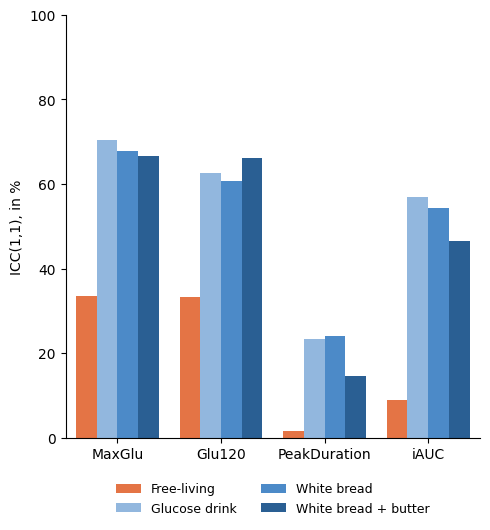

In [21]:
import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt

MEAL_LABELS = {"other":"Free-living", "A":"Glucose drink",
               "B":"White bread", "C":"White bread + butter"}
MEAL_ORDER  = ["Free-living", "Glucose drink", "White bread", "White bread + butter"]
PALETTE     = {"Free-living":"#FF692A", "Glucose drink":"#85B7EB",
               "White bread":"#378ADD", "White bread + butter":"#185FA5"}
OUTCOME_MAP   = {"max_glucose":"MaxGlu","end_glucose":"Glu120",
                 "peak_duration":"PeakDuration","positive_iAUC":"iAUC"}
OUTCOME_ORDER = ["MaxGlu","Glu120","PeakDuration","iAUC"]

sns.reset_defaults()
plot_df = icc_df.copy()
plot_df["meal"]    = plot_df["standardized_meal"].map(MEAL_LABELS)
plot_df["outcome"] = plot_df["outcome"].map(OUTCOME_MAP)
plot_df["ICC_pct"] = 100 * plot_df["ICC1"]          # ICC(1): single-meal between-individual share

fig, ax = plt.subplots(figsize=(5, 5.4))
sns.barplot(data=plot_df, x="outcome", y="ICC_pct", hue="meal",
            order=OUTCOME_ORDER, hue_order=MEAL_ORDER,
            palette=PALETTE, ax=ax)

ax.set_xlabel("")
ax.set_ylabel("ICC(1,1), in %")
ax.set_ylim(0, 100)
ax.set_yticks(np.arange(0, 101, 20))
ax.tick_params(axis="y", which="both", left=True, labelleft=True)
ax.grid(False)
sns.despine(ax=ax)                                 # drop top + right spines
ax.legend(title="", frameon=False, loc="upper center",
          bbox_to_anchor=(0.5, -0.08), ncol=2, fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "panel_1_icc_freeliving_vs_standardized.svg", bbox_inches="tight")
plt.show()